In [1]:
import os

#add the root directory
os.chdir('../')

# Supplementary mateiral: analysis with PCA for the autoignition dataset

In [35]:
import numpy as np
import pandas as pd
from PCAfold import PCA
from PCAfold import remove_constant_vars
import matplotlib.pyplot as plt

In [62]:
filename_autoignition = "isochoric-adiabatic-closed-HR-H2-air-lin_Z_0.015_0.035_100-T0_900-"
path_data_autoignition = "data-files/autoignition/"
path_data = "data-files/"

#create all the datasets
mixture_fractions_train_0D = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}mixture-fraction.csv") #1 x nbr_timesteps
mixture_fractions_test = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}mixture-fractions-test-trajectories.csv") #1 x nbr_test_trajectories
state_space_names = np.genfromtxt(f"{path_data_autoignition}{filename_autoignition}state-space-names.csv", delimiter=",", dtype=str)
state_space_train_0D = pd.read_csv(f"{path_data_autoignition}{filename_autoignition}state-space.csv", names = state_space_names)
state_space_source_train_0D = pd.read_csv(f"{path_data_autoignition}{filename_autoignition}state-space-sources.csv", names = state_space_names)
time_train = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}time.csv") #1 x nbr_timesteps

In [63]:
state_space = state_space_train_0D.drop(columns=["T", "N2", "N2H3", "H2NN"]) #H2NN too small values
state_space_numpy = state_space.to_numpy()

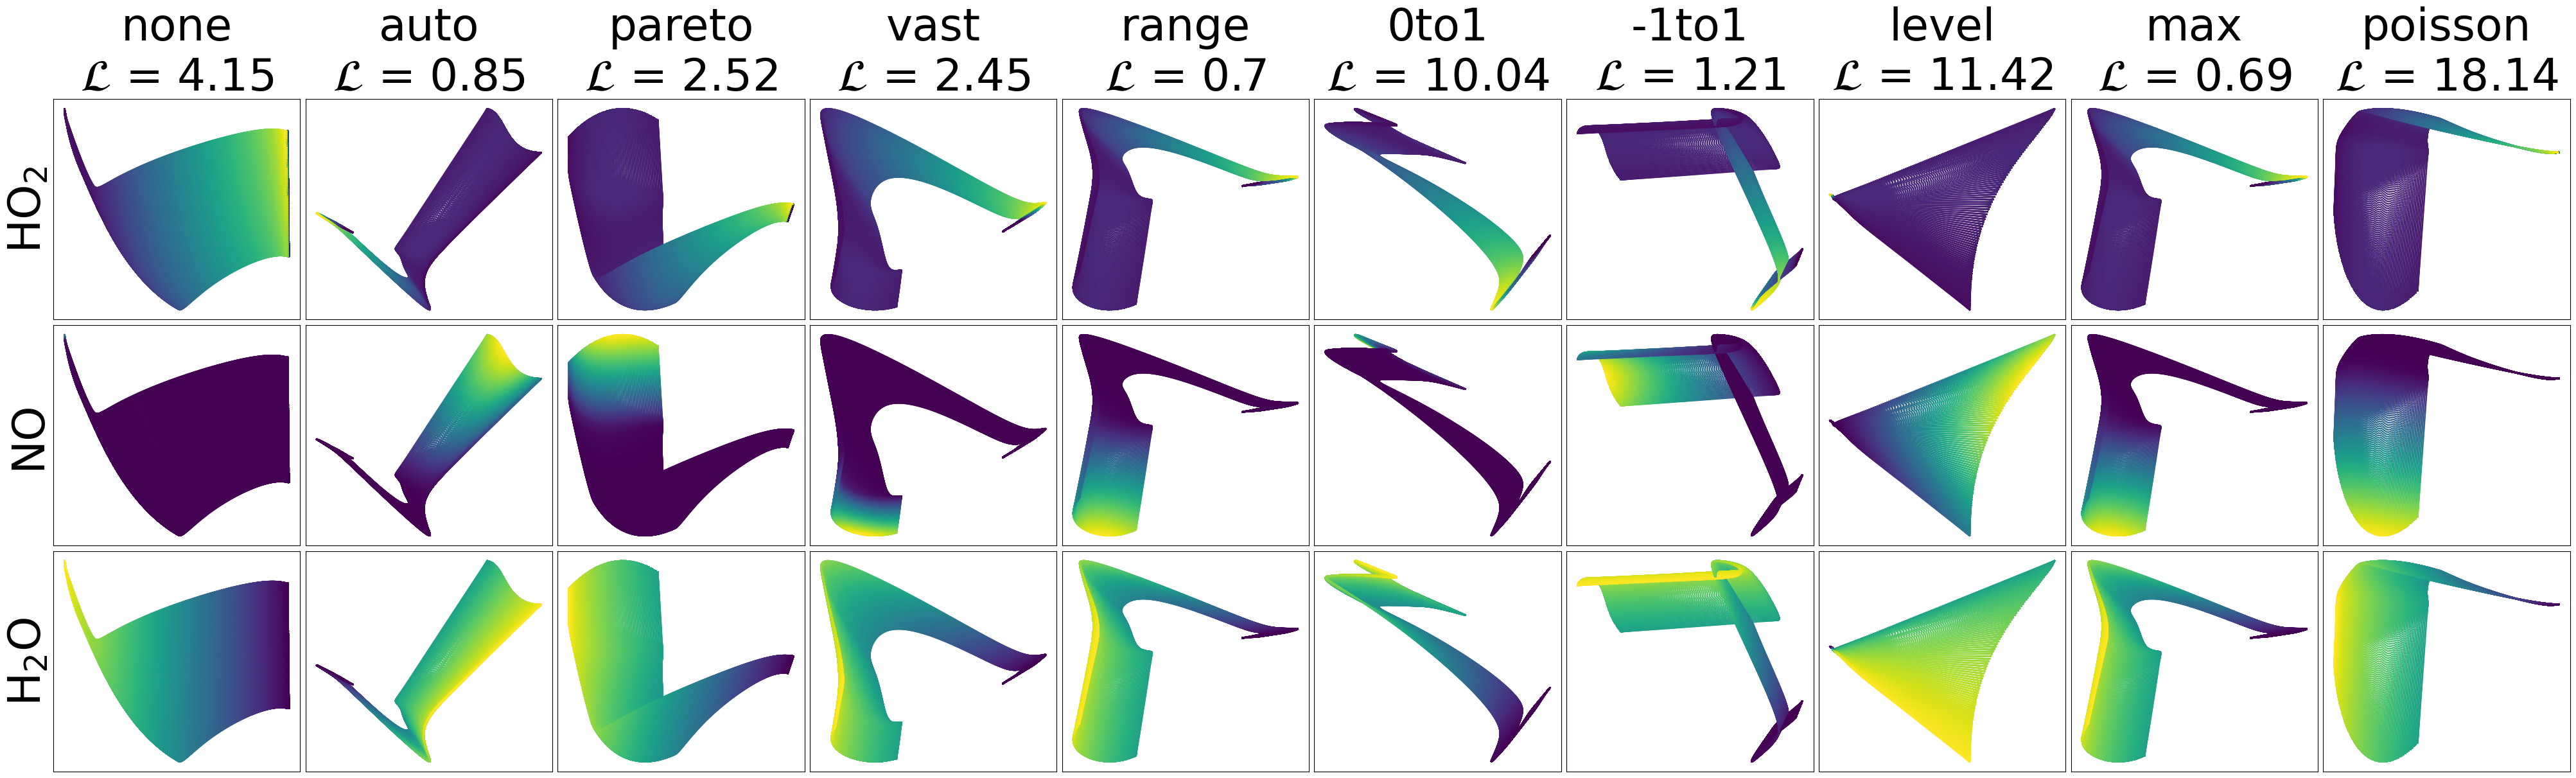

In [64]:
save = True
savePath = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/PCA/"
saveName = "PCA manifolds - different scalings - autoignition - with cost"

set_of_scalings = ["none", "auto", "pareto", "vast", "range", "0to1", "-1to1", "level", "max", "poisson"]
cost_of_scalings = [4.15, 0.85, 2.52, 2.45, 0.70, 10.04, 1.21, 11.42, 0.69, 18.14]

color_variables = ["HO2", "NO", "H2O"]

n_rows = len(color_variables)
n_cols = len(set_of_scalings)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    constrained_layout=True
)

for col_idx, scaling in enumerate(set_of_scalings):

    # PCA
    pca_state_space = PCA(
        state_space_numpy,
        scaling=scaling,
        n_components=2,
        use_eigendec=True,
        nocenter=False
    )

    principal_components = pca_state_space.transform(state_space_numpy)

    # One row per coloring variable
    for row_idx, species in enumerate(color_variables):

        ax = axes[row_idx, col_idx]

        scatter = ax.scatter(
            principal_components[:, 0],
            principal_components[:, 1],
            c=state_space[species],
            s=1
        )

        # Titles only on top row
        if row_idx == 0:
            ax.set_title(f"{scaling}\n" + r"$\mathcal{L}$" + f" = {cost_of_scalings[col_idx]}", fontsize = 50)

        # Y labels only on first column
        if col_idx == 0:
            ax.set_ylabel(species)

        ax.set_xlabel("PC1")
        ax.set_ylabel(f"{species}\nPC2")

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xlabel("")
        if col_idx == 0:
            ax.set_ylabel(f"{species.replace('2', r'$_2$')}", fontsize = 50)
        else:
            ax.set_ylabel("")

if save:
    plt.savefig(savePath + saveName, bbox_inches = "tight", dpi = 300)
plt.show()